# Walk-Forward Optimization (WFO)

This notebook performs Walk-Forward Optimization using the `ggTrader` orchestrator api. It implements a **Robustness-First** selection strategy, picking parameters that perform consistently across multiple time folds rather than just the most recent one.

In [18]:
import sys
import os
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt
from tabulate import tabulate

# Auto-reload custom modules
%load_ext autoreload
%autoreload 2

# Ensure project root is in path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..',  'src'))
if project_root not in sys.path:
    sys.path.append(project_root)

from ggTrader.core.orchestrator import run_wfo_orchestrator
from ggTrader.utils.setup import load_data_and_setup
from ggTrader.utils.utils import make_end_anchored_tscv, plot_cv_indices
print("Environment initialized.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Environment initialized.


In [19]:
# --- Configuration ---
CONSTANTS = {
    "SYMBOLS": None,
    "SYMBOLS_FILE": os.path.join(os.getcwd(), "..",  "data", "top_30_USD_1095_movers.json"),
    "START_DATE": "2023-01-01",
    "END_DATE": "2025-12-31",
    "INTERVAL": "4h",
    "START_CASH": 1000,
    "PORTFOLIO_SHARE": 0.10,
    "FEES": 0.005,
    "N_SPLITS": 5,
    "TEST_RATIO": 0.34,
    "MIN_TRADES": 10,
    "SLIPPAGE": 0.003,
    "USE_MOVERS": 10,
}

print("Configuration loaded.")

Configuration loaded.


In [20]:
# --- Define Parameter Grid ---
params = {
    # entry
    "sar_acceleration": [0.02],
    "sar_maximum": [0.2],
    "use_dmp_cross": [False],
    "adx_threshold": list(range(5, 20, 5)),
    "adx_length": list(range(10, 20, 5)),
    # exit
    "atr_length": list(range(5, 15, 5)),
    "atr_multiplier": list(np.arange(0.5, 6, 0.5)),

}

print("Parameter grid defined.")

Parameter grid defined.


Loading data for split visualization...


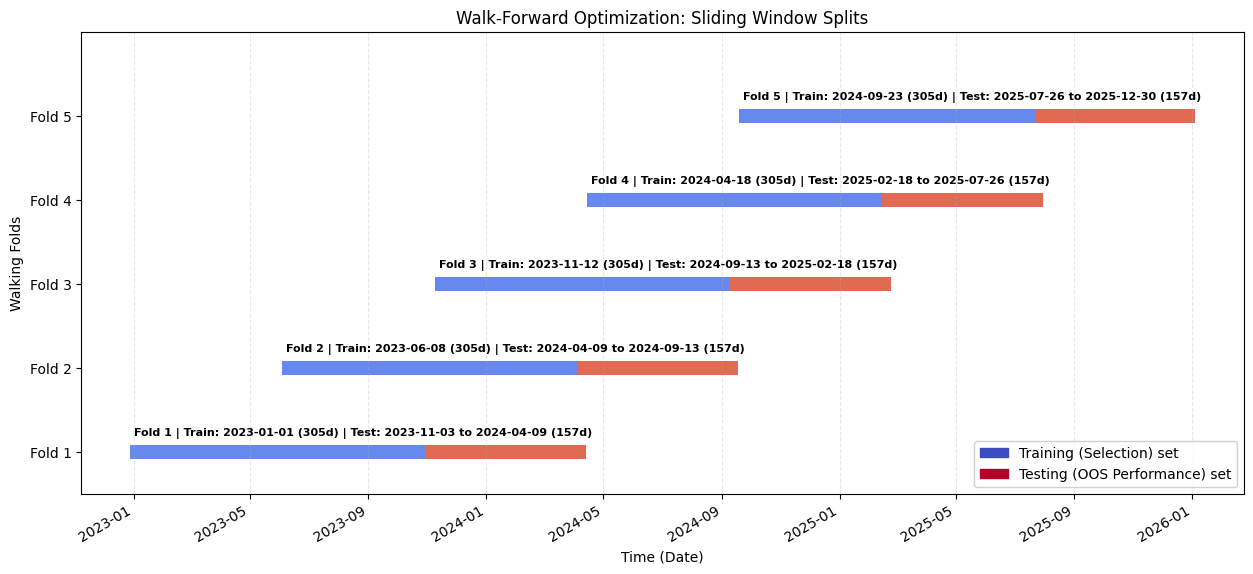

In [21]:
# --- Visualize WFO Splits ---
print("Loading data for split visualization...")
ohlcv = load_data_and_setup(CONSTANTS)

tscv, _, _ = make_end_anchored_tscv(
    n_samples=len(ohlcv),
    n_splits=CONSTANTS["N_SPLITS"],
    test_ratio=CONSTANTS["TEST_RATIO"],
)

fig, ax = plt.subplots(figsize=(15, 6))
plot_cv_indices(tscv, ohlcv.index, ax, CONSTANTS["N_SPLITS"])
plt.show()

In [22]:
# --- Run WFO ---
results = run_wfo_orchestrator(
    config=CONSTANTS, 
    param_grid=params, 
    save_results=False,
    show_progress=True
)

wfo_stats = results["wfo_stats"]
robust_top_5 = results["robust_top_5"]
final_pf = results["final_portfolio"]

print("\nWFO Complete.")

Loading data...
Starting WFO Loop (5 splits)...


  0%|          | 0/132 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  > Fold 1 Keys: ['fold', 'train_start', 'test_start', 'test_end', 'params', 'is_sharpe', 'oos_sharpe', 'sortino', 'profit', 'start_capital', 'end_capital', 'return_pct']
  > Fold 1 Complete.


  0%|          | 0/132 [00:00<?, ?it/s]

...

  0%|          | 0/132 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  > Fold 5 Complete.


  0%|          | 0/1 [00:00<?, ?it/s]


WFO Complete.


In [23]:
# --- Analysis & Visualization ---

print("\nPARAMETER ROBUSTNESS REPORT (Top 5 Overall):")
robust_report_df = pd.DataFrame([{"Score": r["robustness_score"], **r["params"]} for r in robust_top_5])
print(tabulate(robust_report_df, headers="keys", tablefmt="github", showindex=False))

print("\nWFO FOLD RESULTS SUMMARY:")
df_results = pd.DataFrame(wfo_stats)
# Create a concise string for the best params
def simplify_params(d):
    # Only show the params that usually change (e.g., adx and atr)
    return f"ADX:{d.get('adx_threshold')}/{d.get('adx_length')} | ATR:{d.get('atr_multiplier')}"

df_clean = df_results.copy()
df_clean['params'] = df_clean['params'].apply(simplify_params)
df_clean['train'] = pd.to_datetime(df_clean['train_start']).dt.strftime('%Y-%m-%d')
df_clean['test'] = pd.to_datetime(df_clean['test_start']).dt.strftime('%Y-%m-%d')

# Select only the readable columns
cols = ['fold', 'train', 'test', 'params', 'is_sharpe', 'oos_sharpe', 'profit']
print(tabulate(df_clean[cols], headers='keys', tablefmt='github', showindex=False))





PARAMETER ROBUSTNESS REPORT (Top 5 Overall):
|   Score |   adx_length |   adx_threshold |   sar_acceleration |   sar_maximum |   use_dmp_cross |   atr_length |   atr_multiplier |
|---------|--------------|-----------------|--------------------|---------------|-----------------|--------------|------------------|
| 1.43579 |           15 |              10 |               0.02 |           0.2 |               0 |            5 |              0.5 |
| 1.43    |           10 |               5 |               0.02 |           0.2 |               0 |           10 |              0.5 |
| 1.42894 |           10 |               5 |               0.02 |           0.2 |               0 |            5 |              0.5 |
| 1.42686 |           10 |              10 |               0.02 |           0.2 |               0 |           10 |              0.5 |
| 1.42538 |           10 |              10 |               0.02 |           0.2 |               0 |            5 |              0.5 |

WFO FOLD RESULT

In [24]:
from tabulate import tabulate

# --- Visualization ---
print("Global Portfolio Stats:")
# Convert stats to a DataFrame for a cleaner table view
stats_df = final_pf.stats().to_frame(name="Value").reset_index()

# 2. Format only the numbers to 2 decimals (ignoring dates and durations)
def format_values(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.2f}"
    return str(x)
stats_df["Value"] = stats_df["Value"].apply(format_values)

# 3. Print with tabulate (no floatfmt needed now because we formatted them in step 2)
print(tabulate(stats_df, headers=["Metric", "Value"], tablefmt="simple", numalign="right", showindex=False))


Global Portfolio Stats:
Metric                      Value
--------------------------  -------------------------
Start                       2023-01-01 00:00:00+00:00
End                         2025-12-30 16:00:00+00:00
Period                      1094 days 20:00:00
Start Value                 1000.00
End Value                   3235.47
Total Return [%]            223.55
Benchmark Return [%]        210.30
Max Gross Exposure [%]      85.66
Total Fees Paid             5306.37
Max Drawdown [%]            34.48
Max Drawdown Duration       293 days 20:00:00
Total Trades                5364
Total Closed Trades         5352
Total Open Trades           12
Open Trade PnL              -24.67
Win Rate [%]                35.28
Best Trade [%]              298.15
Worst Trade [%]             -38.21
Avg Winning Trade [%]       8.08
Avg Losing Trade [%]        -3.45
Avg Winning Trade Duration  4 days 06:36:59.491525423
Avg Losing Trade Duration   2 days 10:45:47.806004618
Profit Factor               1.

In [25]:
print("\nFinal Model Performance (Full History with Best Robust Params):")
final_pf.plot(subplots= ['drawdowns','value','cum_returns']).show()


Final Model Performance (Full History with Best Robust Params):
